In [1]:
import numpy as np
from matplotlib import pyplot as plt
from time import time
import PT_model
from PT_model import Acoustic_2D_Cartesian_Grid
import PT_data_classes
from copy import copy
import PT_data 

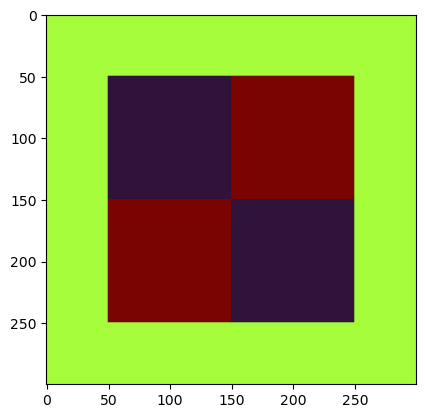

In [2]:
model = PT_model.load_model("Box_Model")

plt.imshow(model.model_params.c, cmap="turbo")

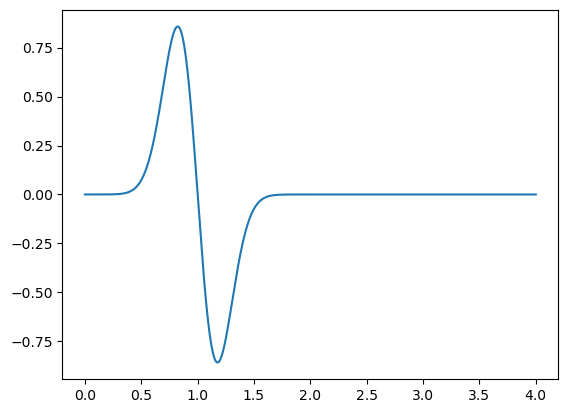

In [3]:
# set time parameters
T_max = 4.0
delta_t = model.model_params.h / (2.0 * np.max(model.model_params.c))  # CFL condition
Nt: int = int(T_max / delta_t) + 1
t = np.arange(Nt) * delta_t

# create first derivative of a gaussian STF
STFS = np.zeros((Nt, 1))
f_0 = 1.
t_0 = 1/f_0
stf = -8. * (t - t_0) * f_0 * (np.exp(-1.0 * (4*f_0) ** 2 * (t - t_0) ** 2))

plt.plot(t, stf)
STFS[:, 0] = stf

In [4]:
# create locations of sources
source_inds = []
source_inds.append((50, 40))

# create locations of receivers
rec_inds = []
for i in range(50, 250, 1):
	rec_inds.append((i, 260))
	
# initioalize aquisition parameters
aquisition_params = PT_data_classes.Aquisition_params(Nt=Nt,
                                                      delta_t=delta_t,
                                                      STFS=STFS,
                                                      source_inds=source_inds,
                                                      rec_inds=rec_inds)

# create save indice
save_inds = np.arange(0, Nt+1).tolist()
save_inds = save_inds[::5]

In [5]:
# call the forward solver

start = time()

u_out, SG = model.forward(aquisition_params=aquisition_params,
                    save_inds=save_inds)[0:2]
end = time()

print(end-start)

0.8332548141479492


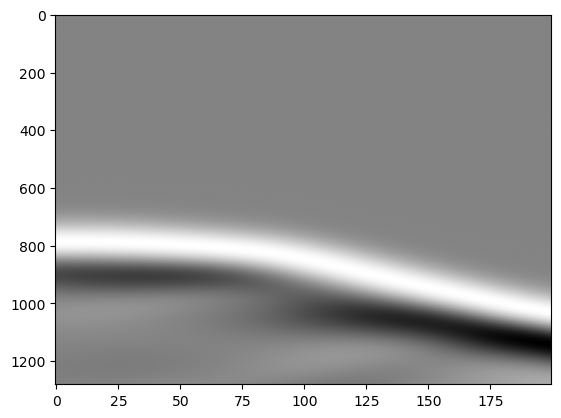

In [6]:
plt.imshow(SG / np.max(SG, axis=0), cmap="gray", aspect="auto")

In [7]:
# list of all functions needed

Ns = 5

model_list = []
aquisition_params_list = []
source_inds_list = [[(int(x), 40)] for x in np.round(np.linspace(50, 250, Ns))]

for i in range(Ns):
	model_list.append(model)
	aquisition_params_list.append(copy(aquisition_params))
	aquisition_params_list[i].source_inds = source_inds_list[i]
	

In [8]:
from PT_routines import Compute_Data_Set

data_set = Compute_Data_Set(model_list=model_list,
							aquisition_params_list=aquisition_params_list)

In [9]:

path = "Box_Data"
data_set.save_data_set(path)
del data_set

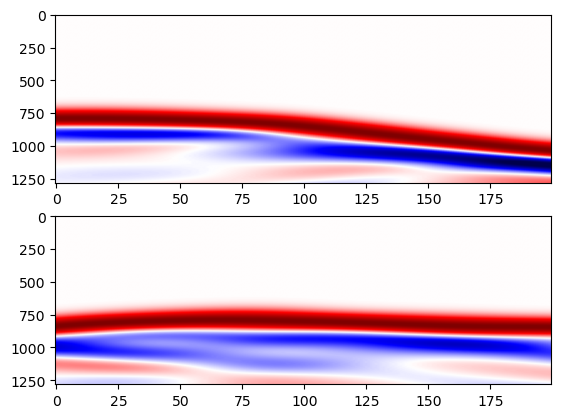

In [10]:
# load and plot data 

data_set = PT_data.load_data_set(path)

SG1 = data_set.shot_gathers[0].gather
SG2 = data_set.shot_gathers[-3].gather

plt.subplot(2,1,1)
plt.imshow(SG1 / np.max(SG1, axis=0), vmin=-0.99, vmax=0.99, cmap="seismic", aspect="auto")

plt.subplot(2,1,2)
plt.imshow(SG2 / np.max(SG2, axis=0), vmin=-0.99, vmax=0.99, cmap="seismic", aspect="auto")

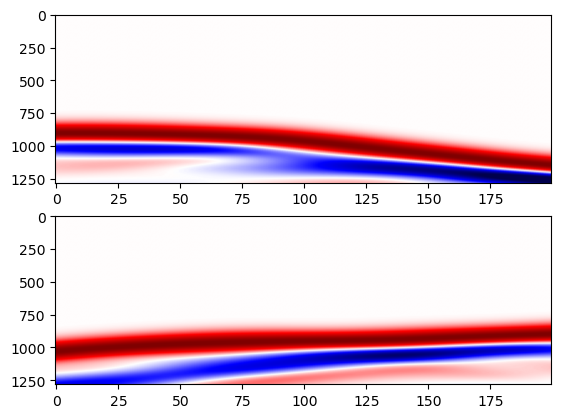

In [11]:
data_set.lowpass_filter(cutoff_freq=3.0, order=10)
data_set.normalize()

SG1 = data_set.shot_gathers[0].gather
SG2 = data_set.shot_gathers[-1].gather

plt.subplot(2,1,1)
plt.imshow(SG1, vmin=-0.99, vmax=0.99, cmap="seismic", aspect="auto")

plt.subplot(2,1,2)
plt.imshow(SG2, vmin=-0.99, vmax=0.99, cmap="seismic", aspect="auto")